In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely as shp
import keyring
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import geoplot as gplt

In [3]:
# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

<Axes: >

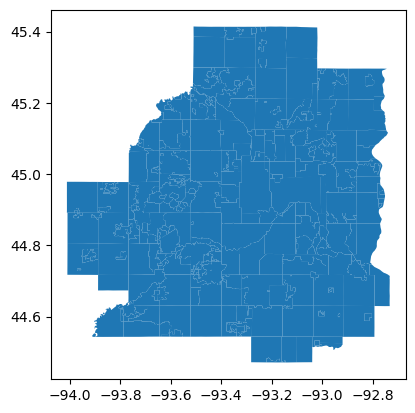

In [4]:
communities = gpd.read_file("shp_society_thrive_msp2040_com_des")
communities = communities.to_crs("EPSG:4326")
communities.plot()

In [5]:
df = pd.read_csv(data_dir + "/data_processed/feasible_shifts.csv")
df

C:\Users\fishl\AppData\Local\Temp\ipykernel_8028\748887692.py:1: DtypeWarning: Columns (34,35,36,53,65,66,67,68,69,70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_dir + "/data_processed/feasible_shifts.csv")


,Unnamed: 0.1,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,...,high_stress_biking_pct,feasible_high_lts_biking,walk_duration,feasible_walking,feasible_timing_walking,bike_duration,feasible_biking,feasible_timing_biking,feasible_transit,feasible_timing_transit
0,0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,...,0.115504,False,355.200000,True,True,233.378333,True,True,True,True
1,1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,...,0.115504,False,355.200000,True,True,233.378333,True,True,True,True
2,2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,...,0.029462,False,180.808333,True,True,169.426667,True,True,True,True
3,3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,...,0.029456,False,180.808333,True,True,169.548333,True,True,True,True
4,4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,...,0.022491,False,171.505000,True,True,142.428333,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454176,454176,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,...,0.005329,True,45.855000,True,True,46.371667,True,True,True,True
454177,454177,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,...,0.031797,False,70.800000,True,True,71.931667,True,True,True,True
454178,454178,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,...,0.031797,False,70.800000,True,True,71.931667,True,True,True,True
454179,454179,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,...,0.030658,True,53.510000,True,True,42.416667,True,True,True,True


In [6]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["home_lon"], df["home_lat"]), crs="EPSG:4326")
gdf

,Unnamed: 0.1,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,...,feasible_high_lts_biking,walk_duration,feasible_walking,feasible_timing_walking,bike_duration,feasible_biking,feasible_timing_biking,feasible_transit,feasible_timing_transit,geometry
0,0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,...,False,355.200000,True,True,233.378333,True,True,True,True,POINT (-92.76657 44.65329)
1,1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,...,False,355.200000,True,True,233.378333,True,True,True,True,POINT (-92.76657 44.65329)
2,2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,...,False,180.808333,True,True,169.426667,True,True,True,True,POINT (-92.76657 44.65329)
3,3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,...,False,180.808333,True,True,169.548333,True,True,True,True,POINT (-92.76657 44.65329)
4,4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,...,False,171.505000,True,True,142.428333,True,True,True,True,POINT (-92.76657 44.65329)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454176,454176,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,...,True,45.855000,True,True,46.371667,True,True,True,True,POINT (-93.17247 44.93089)
454177,454177,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,...,False,70.800000,True,True,71.931667,True,True,True,True,POINT (-93.38229 45.04030)
454178,454178,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,...,False,70.800000,True,True,71.931667,True,True,True,True,POINT (-93.38229 45.04030)
454179,454179,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,...,True,53.510000,True,True,42.416667,True,True,True,True,POINT (-93.38229 45.04030)


In [7]:
gdf["community"] = "na"
for i, row in communities.iterrows():
    gdf["community"] = np.where(gdf["geometry"].within(row["geometry"]), row.name, gdf["community"])
gdf["community"].value_counts()

community
142    90282
na     58384
192    55916
91      9650
122     9481
       ...  
264        3
220        3
206        2
14         2
72         2
Name: count, Length: 214, dtype: int64

In [8]:
valid_modes = [("Car","distance"), 
               ("Bike/Scooter","distance"), 
               ("Walk","distance"), 
               ("Transit","distance")]

def plot_mode_density(df: pd.DataFrame, modes=valid_modes, percentile=0.95, size=(12, 6), bins=300, function=lambda x: x, ax=None, fig=None):
    palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
    if (ax == None):
        fig, ax = plt.subplots(figsize=size)
    for m in modes: # cycle through all modes
        mode = m[0]
        column = m[1]
        label = mode + ' ' + column
        
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(function(group[column]), ax=ax, stat="density", kde=True, label=label, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = function(group[column]).quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        ax.axvline(x=val, color=c) # plot line representing that value on the plot        
        ax.legend()
    return fig, ax

In [9]:
from matplotlib.colors import LinearSegmentedColormap
rg=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256) 
rg.set_bad(color="grey")

In [10]:
gdf_subset = gdf.loc[gdf["community"] != "na", :].copy()

In [11]:
import plotly.express as px

In [12]:
def view(percentile):
    # fig, ax = plot_mode_density(df, [('Walk','walk_distance_miles'), ('Car','walk_distance_miles')], percentile=percentile)
    # ax.set_xlim(left=0, right=40)
    
    #| output: true

    # set the maximum feasible walking distance to WALK_DISTANCE_CUTOFF (default 1.6 miles)
    gdf_subset["within_feasible_walking_dist"] = True
    
    cutoff = gdf[gdf["mode"] == "Walk"]["walk_distance_miles"].quantile(percentile)

    gdf_subset.loc[gdf_subset['walk_distance_miles'] > cutoff, 'feasible_walk_shift'] = False
    gdf_subset.loc[gdf_subset["walk_distance_miles"] > cutoff, "within_feasible_walking_dist"] = False
    
    communities["val"] = (gdf_subset.groupby("community")["within_feasible_walking_dist"].sum() / gdf_subset.groupby("community")["within_feasible_walking_dist"].count()).fillna(0)
    
    gplt.choropleth(communities, hue=communities["val"], projection=gplt.crs.AlbersEqualArea(), cmap=rg, figsize=(12, 12))


In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [14]:
#| output: true
%matplotlib inline
from ipywidgets import interact, FloatSlider

interact(view, percentile=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.95))

interactive(children=(FloatSlider(value=0.95, description='percentile', max=0.99, min=0.01, step=0.01), Output…

<function __main__.view(percentile)>